In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
warnings.filterwarnings('ignore')


2026-04-29 05:28:40.327028: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777440520.511016      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777440520.564979      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777440520.974320      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777440520.974357      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777440520.974360      57 computation_placer.cc:177] computation placer alr

In [2]:

# ================================================================
# STEP 1: PATHS AND SETTINGS
# ================================================================

TRAIN_PATH = "/kaggle/input/datasets/dhruvmak/face-mask-detection/dataset"
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 10


In [3]:

# ================================================================
# STEP 2: DATA AUGMENTATION AND LOADING
# ================================================================

train_datagen = ImageDataGenerator(
    rescale            = 1./255,
    rotation_range     = 20,
    width_shift_range  = 0.2,
    height_shift_range = 0.2,
    zoom_range         = 0.2,
    horizontal_flip    = True,
    validation_split   = 0.2
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'binary',
    subset      = 'training'
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'binary',
    subset      = 'validation'
)

print("Classes Found:", train_generator.class_indices)
print(f"Training Samples:   {train_generator.samples}")
print(f"Validation Samples: {val_generator.samples}")


Found 352 images belonging to 2 classes.
Found 88 images belonging to 2 classes.
Classes Found: {'with_mask': 0, 'without_mask': 1}
Training Samples:   352
Validation Samples: 88


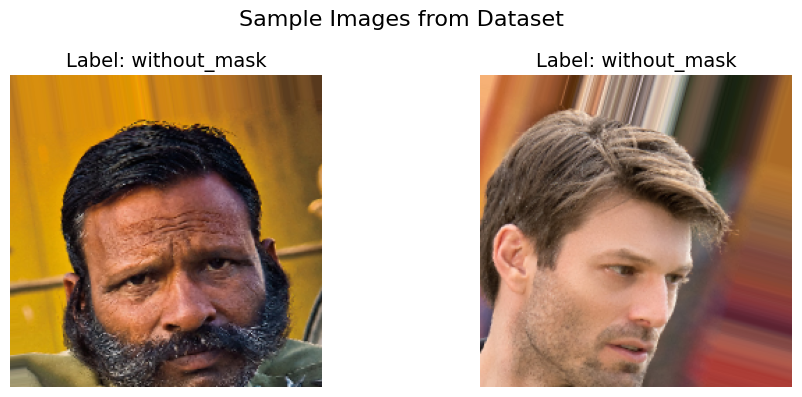

I0000 00:00:1777440576.126801      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777440576.132911      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
VGG16 Loaded  - Total Layers: 19


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [4]:

# ================================================================
# STEP 3: SHOW 2 SAMPLE IMAGES
# ================================================================

images, labels = next(train_generator)
class_names    = {v: k for k, v in train_generator.class_indices.items()}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i in range(2):
    axes[i].imshow(images[i])
    axes[i].set_title(f"Label: {class_names[int(labels[i])]}", fontsize=14)
    axes[i].axis('off')
plt.suptitle("Sample Images from Dataset", fontsize=16)
plt.tight_layout()
plt.show()

# ================================================================
# STEP 4: LOAD VGG16 (Transfer Learning)
# ================================================================

base_model = VGG16(
    weights     = 'imagenet',
    include_top = False,
    input_shape = (224, 224, 3)
)

base_model.trainable = False

print(f"VGG16 Loaded  - Total Layers: {len(base_model.layers)}")

# ================================================================
# STEP 5: BUILD FULL MODEL
# ================================================================

model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.0001),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)

model.summary()


In [5]:

# ================================================================
# STEP 6: TRAIN THE MODEL
# ================================================================

history = model.fit(
    train_generator,
    epochs          = EPOCHS,
    validation_data = val_generator
)


Epoch 1/10


I0000 00:00:1777440598.558215     151 service.cc:152] XLA service 0x7cd3c400cba0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777440598.558250     151 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777440598.558256     151 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777440599.060071     151 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/11 ━━━━━━━━━━━━━━━━━━━━ 2:51 17s/step - accuracy: 0.5938 - loss: 0.8218

I0000 00:00:1777440613.139072     151 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


11/11 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.5494 - loss: 0.7670 - val_accuracy: 0.5227 - val_loss: 0.6812
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.4971 - loss: 0.7347 - val_accuracy: 0.7159 - val_loss: 0.6560
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 995ms/step - accuracy: 0.5711 - loss: 0.6955 - val_accuracy: 0.8295 - val_loss: 0.6334
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.5701 - loss: 0.6802 - val_accuracy: 0.9091 - val_loss: 0.6124
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.5806 - loss: 0.7070 - val_accuracy: 0.8750 - val_loss: 0.5953
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 968ms/step - accuracy: 0.6291 - loss: 0.6399 - val_accuracy: 0.9091 - val_loss: 0.5788
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.6988 - loss: 0.5906 - val_accuracy: 0.8864 - val_loss: 0.5631
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.6874 - loss: 0.5900 - val_accuracy: 0.9545 - val_loss: 0.54

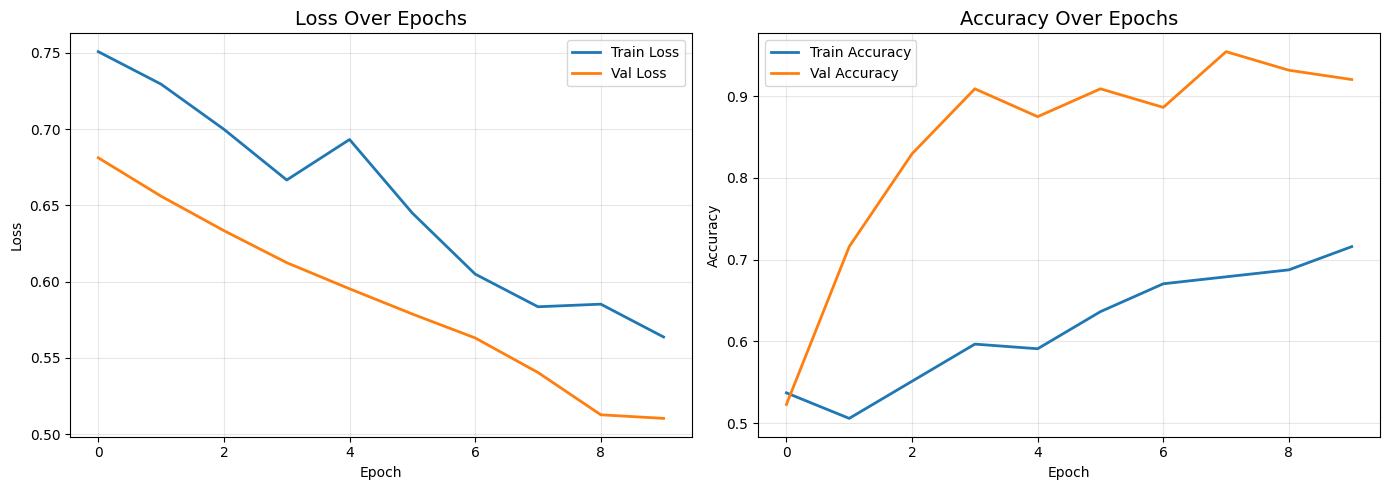

In [6]:

# ================================================================
# STEP 7: PLOT TRAINING RESULTS
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss',   linewidth=2)
axes[0].set_title('Loss Over Epochs', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2)
axes[1].set_title('Accuracy Over Epochs', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 846ms/step


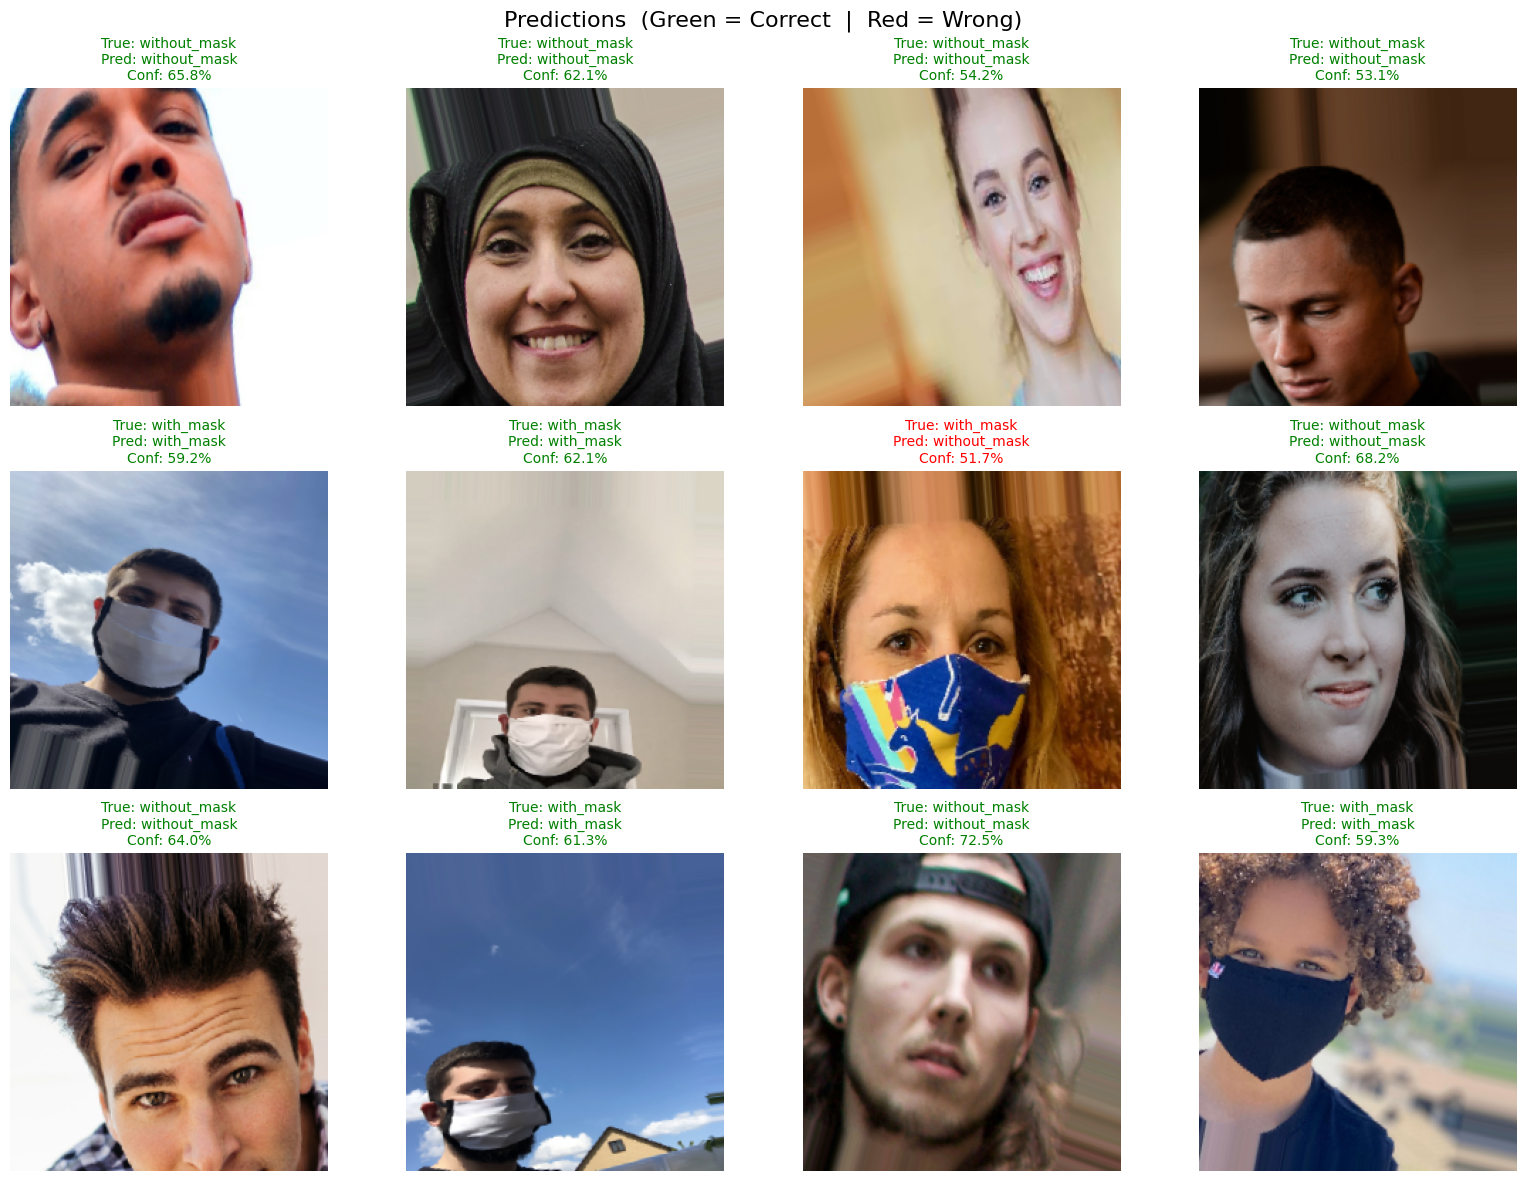

In [7]:

# ================================================================
# STEP 8: PLOT PREDICTIONS ON VALIDATION IMAGES
# ================================================================

val_images, val_labels = next(val_generator)

predictions = model.predict(val_images)
pred_labels = (predictions > 0.5).astype(int).flatten()

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes      = axes.flatten()

for i in range(12):
    axes[i].imshow(val_images[i])

    true_label = class_names[int(val_labels[i])]
    pred_label = class_names[pred_labels[i]]
    confidence = predictions[i][0] if pred_labels[i] == 1 else 1 - predictions[i][0]

    color = 'green' if true_label == pred_label else 'red'

    axes[i].set_title(
        f"True: {true_label}\nPred: {pred_label}\nConf: {confidence*100:.1f}%",
        color    = color,
        fontsize = 10
    )
    axes[i].axis('off')

plt.suptitle("Predictions  (Green = Correct  |  Red = Wrong)", fontsize=16)
plt.tight_layout()
plt.show()


In [8]:

# ================================================================
# STEP 9: FINAL ACCURACY
# ================================================================

val_loss, val_acc = model.evaluate(val_generator)
print(f"\nFinal Validation Loss:     {val_loss:.4f}")
print(f"Final Validation Accuracy: {val_acc*100:.2f}%")

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 684ms/step - accuracy: 0.9446 - loss: 0.5008

Final Validation Loss:     0.5063
Final Validation Accuracy: 92.05%


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: with_mask
Confidence: 62.42%


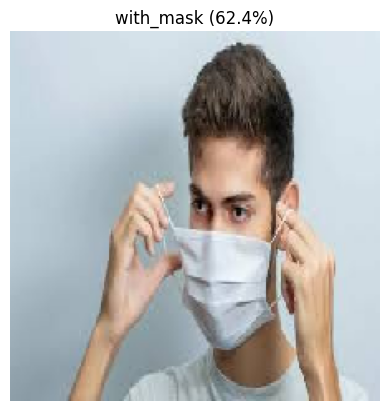

In [9]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_single_image(img_path, model, class_names):
    # 1. Load and resize the image
    img = image.load_img(img_path, target_size=(224, 224))
    
    # 2. Convert to array and normalize (1./255)
    img_array = image.img_to_array(img) / 255.0
    
    # 3. Add batch dimension: (224, 224, 3) -> (1, 224, 224, 3)
    img_batch = np.expand_dims(img_array, axis=0)
    
    # 4. Make prediction
    prediction = model.predict(img_batch)
    
    # 5. Interpret the result
    # For binary classification: 0 is usually 'with_mask' and 1 is 'without_mask' 
    # (depending on your folder names alphabetical order)
    prob = prediction[0][0]
    pred_label = 1 if prob > 0.5 else 0
    confidence = prob if pred_label == 1 else 1 - prob
    
    class_label = class_names[pred_label]
    
    print(f"Prediction: {class_label}")
    print(f"Confidence: {confidence * 100:.2f}%")
    
    # Optional: Display the image
    plt.imshow(img)
    plt.title(f"{class_label} ({confidence * 100:.1f}%)")
    plt.axis('off')
    plt.show()
/kaggle/input/datasets/dhruvmak/face-mask-detection/dataset/without_mask/image_1.png
# ==========================================
# TEST IT ON YOUR IMAGE
# ==========================================
# Replace 'your_test_image.jpg' with your actual file path
my_image_path = "/kaggle/input/datasets/huzifaulhaq/without-mask/images.jpg" 
predict_single_image(my_image_path, model, class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Prediction: without_mask
Confidence: 68.73%


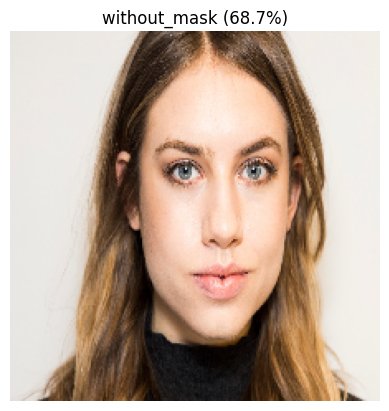

In [11]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_single_image(img_path, model, class_names):
    # 1. Load and resize the image
    img = image.load_img(img_path, target_size=(224, 224))
    
    # 2. Convert to array and normalize (1./255)
    img_array = image.img_to_array(img) / 255.0
    
    # 3. Add batch dimension: (224, 224, 3) -> (1, 224, 224, 3)
    img_batch = np.expand_dims(img_array, axis=0)
    
    # 4. Make prediction
    prediction = model.predict(img_batch)
    
    # 5. Interpret the result
    # For binary classification: 0 is usually 'with_mask' and 1 is 'without_mask' 
    # (depending on your folder names alphabetical order)
    prob = prediction[0][0]
    pred_label = 1 if prob > 0.5 else 0
    confidence = prob if pred_label == 1 else 1 - prob
    
    class_label = class_names[pred_label]
    
    print(f"Prediction: {class_label}")
    print(f"Confidence: {confidence * 100:.2f}%")
    
    # Optional: Display the image
    plt.imshow(img)
    plt.title(f"{class_label} ({confidence * 100:.1f}%)")
    plt.axis('off')
    plt.show()
# ==========================================
# TEST IT ON YOUR IMAGE
# ==========================================
# Replace 'your_test_image.jpg' with your actual file path
my_image_path = "/kaggle/input/datasets/dhruvmak/face-mask-detection/dataset/without_mask/image_1.png" 
predict_single_image(my_image_path, model, class_names)

# Birds Species Dataset

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import os
import warnings
warnings.filterwarnings('ignore')


In [17]:

# ================================================================
# STEP 1: PATHS AND SETTINGS
# ================================================================

TRAIN_PATH = "/kaggle/input/datasets/akash2907/bird-species-classification/train_data/train_data"
TEST_PATH  = "/kaggle/input/datasets/akash2907/bird-species-classification/test_data/test_data"
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 10


In [18]:

# ================================================================
# STEP 2: DATA AUGMENTATION AND LOADING (CATEGORICAL)
# ================================================================

# Augmentation for training
train_datagen = ImageDataGenerator(
    rescale            = 1./255,
    rotation_range     = 30,
    width_shift_range  = 0.2,
    height_shift_range = 0.2,
    shear_range        = 0.2,
    zoom_range         = 0.2,
    horizontal_flip    = True,
    fill_mode          = 'nearest'
)

# Only rescaling for testing/validation
test_datagen = ImageDataGenerator(rescale = 1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical' # Changed to categorical for many species
)

val_generator = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical'
)

# Get dynamic number of classes and class names
NUM_CLASSES = len(train_generator.class_indices)
class_names = {v: k for k, v in train_generator.class_indices.items()}

print(f"\nTotal Bird Species Detected: {NUM_CLASSES}")
print(f"Training Samples: {train_generator.samples}")

# ================================================================
# STEP 3: LOAD VGG16 (Transfer Learning)
# ================================================================

base_model = VGG16(
    weights     = 'imagenet',
    include_top = False,
    input_shape = (224, 224, 3)
)

base_model.trainable = False # Freeze VGG16 layers


Found 150 images belonging to 16 classes.
Found 157 images belonging to 16 classes.

Total Bird Species Detected: 16
Training Samples: 150


In [19]:

# ================================================================
# STEP 4: BUILD MULTI-CLASS MODEL
# ================================================================

model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax') # Softmax gives probabilities for all classes
])

model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.0001),
    loss      = 'categorical_crossentropy', # Required for multi-class
    metrics   = ['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │         8,208 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,985,552 (57.17 MB)

 Trainable params: 270,864 (1.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [20]:

# ================================================================
# STEP 5: TRAIN THE MODEL
# ================================================================

history = model.fit(
    train_generator,
    epochs          = EPOCHS,
    validation_data = val_generator
)


Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 99s 23s/step - accuracy: 0.0801 - loss: 2.9993 - val_accuracy: 0.0446 - val_loss: 2.8908
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 45s 10s/step - accuracy: 0.0516 - loss: 2.9183 - val_accuracy: 0.0446 - val_loss: 2.8246
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 43s 10s/step - accuracy: 0.0872 - loss: 2.8835 - val_accuracy: 0.0382 - val_loss: 2.7726
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 43s 10s/step - accuracy: 0.0279 - loss: 2.8132 - val_accuracy: 0.0764 - val_loss: 2.7332
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 44s 10s/step - accuracy: 0.1128 - loss: 2.8042 - val_accuracy: 0.1529 - val_loss: 2.7048
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 44s 10s/step - accuracy: 0.1069 - loss: 2.7962 - val_accuracy: 0.1656 - val_loss: 2.6826
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 42s 10s/step - accuracy: 0.1181 - loss: 2.6989 - val_accuracy: 0.1592 - val_loss: 2.6657
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 45s 10s/step - accuracy: 0.0927 - loss: 2.7631 - val_accuracy: 0.1592 - val_loss: 2.6516


In [ ]:

# ================================================================
# STEP 6: PLOT TRAINING RESULTS
# ================================================================

def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss Plot
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title('Loss History')
    axes[0].legend()
    
    # Accuracy Plot
    axes[1].plot(history.history['accuracy'], label='Train Acc')
    axes[1].plot(history.history['val_accuracy'], label='Val Acc')
    axes[1].set_title('Accuracy History')
    axes[1].legend()
    
    plt.show()

plot_history(history)


In [ ]:

# ================================================================
# STEP 7: PREDICTION FUNCTION FOR SINGLE IMAGE
# ================================================================

def predict_bird_species(img_path, model, class_names):
    # Load and preprocess image
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0) # Add batch dimension
    
    # Make prediction
    preds = model.predict(img_batch)
    top_idx = np.argmax(preds[0]) # Index of highest probability
    confidence = preds[0][top_idx]
    
    result = class_names[top_idx]
    
    print(f"\n--- Prediction Result ---")
    print(f"Species: {result}")
    print(f"Confidence: {confidence*100:.2f}%")
    
    plt.imshow(img)
    plt.title(f"Pred: {result} ({confidence*100:.1f}%)")
    plt.axis('off')
    plt.show()

# To use it, simply provide an image path:
# predict_bird_species("path/to/test/image.jpg", model, class_names)